In [1]:
import pandas as pd
path = "data/macrotopics_pred.csv"
df = pd.read_csv(path)

In [2]:
print(f"Número de linhas: {len(df)}")
df = df[df['macrotopic_pred'] != 'Others']
print(f"Número de linhas após filtrar 'Others': {len(df)}")
df = df[df['perspective_toxicity'].notna()]
print(f"Número de linhas após filtrar valores nulos em 'perspective_toxicity': {len(df)}")

Número de linhas: 673587
Número de linhas após filtrar 'Others': 427960
Número de linhas após filtrar valores nulos em 'perspective_toxicity': 427959


In [3]:
import ast

def safe_eval(val):
    # Verifica se é string. Se for NaN ou outro tipo, retorna o próprio valor
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

df['occurrences'] = df['occurrences'].map(safe_eval)

In [4]:
def calculate_transfer_time(row):
    occurrences = row['occurrences']

    if not occurrences:
        return None

    first_appearance_str = min(occurrences, key=lambda x: x['date'])['date']

    first_date = pd.to_datetime(first_appearance_str).tz_localize(None)
    published_at = pd.to_datetime(row['published_at']).tz_localize(None)

    diff = (first_date - published_at).days
    return max(0, diff)

df['transfer_time'] = df.apply(calculate_transfer_time, axis=1)
df['first_appearance'] = df['occurrences'].apply(lambda occ: min(occ, key=lambda x: x['date'])['date'] if occ else None)

In [7]:
df['published_at'].iloc[1]

'2024-10-27T04:30:04Z'

In [32]:
df_exploded = df.explode('occurrences').reset_index(drop=True)
df_normalized = pd.json_normalize(df_exploded['occurrences'])
df_complete = pd.concat([
    df_exploded.drop(columns=['occurrences']), 
    df_normalized
], axis=1)
df_resumo = df_complete.groupby('video_id').agg({
    'lifetime': 'first',               
    'send_count': 'first',            
    'folder': 'nunique',
    'transfer_time': 'first',                   
    'macrotopic_pred': 'first',             
    'perspective_toxicity': 'mean'         
}).reset_index()

In [33]:
df_resumo=df_resumo[df_resumo['macrotopic_pred']!='Others']
df_resumo=df_resumo[~df_resumo['perspective_toxicity'].isna()]

In [34]:
df_resumo

,video_id,lifetime,send_count,folder,transfer_time,macrotopic_pred,perspective_toxicity
0,---HJCJANEk,1.0,1,1,1937.0,Religion,0.023995
1,---iaPiiOlg,1.0,1,1,163.0,Entertainment,0.167652
2,--01APk266U,1.0,1,1,3633.0,Entertainment,0.008406
3,--0HDiV4Wrk,1.0,1,1,85.0,Foreign Policy,0.005799
4,--0WrRVhu20,1.0,10,9,0.0,"Crime, Security and Justice",0.008402
...,...,...,...,...,...,...,...
427954,zzvvyGS2xqk,1.0,1,1,16.0,War,0.242826
427955,zzws83G55VM,1.0,1,1,1744.0,Entertainment,0.023890
427956,zzx_N1awHJg,1.0,1,1,0.0,War,0.003605
427957,zzxa6uprWlQ,1.0,1,1,0.0,War,0.074256


In [35]:
politics=['American Politics','Foreign Policy','War','Crime, Security and Justice']
non_politics=['Religion',
'Entertainment',
'Hobbies',
'Health',
'Environment',
'Technology'
]

In [36]:
df.value_counts('macrotopic_pred')

macrotopic_pred
Religion                       111071
Entertainment                  110639
American Politics               52998
War                             52846
Foreign Policy                  40410
Hobbies                         18913
Health                          11522
Environment                     11500
Crime, Security and Justice      9341
Technology                       8719
Name: count, dtype: int64

In [37]:
from scipy.stats import mannwhitneyu

perspective_toxicity=['perspective_toxicity','perspective_severe_toxicity','perspective_insult',
       'perspective_obscene', 'perspective_threat','perspective_identity_attack']
toxicity_by_topic={}
print('|   |'+'|'.join(perspective_toxicity)+'|')
print('|---|'+'|'.join(['---' for _ in perspective_toxicity])+'|')

for idx,df_group in df.groupby('macrotopic_pred'):
    df_others=df[df['macrotopic_pred']!=idx]
    line=[idx]
    for axis in perspective_toxicity:
        median_str=str(round(df_group[axis].mean(),3))
        if mannwhitneyu(df_group[axis].to_list(),df_others[axis].to_list(),alternative='greater').pvalue<0.05/60: #Bonferroni Correction: 10 topics * 6 axis
            median_str+='*'
            
        
        line.append(median_str)

    print('|'+'|'.join(line)+'|')

print('|---|'+'|'.join(['---' for _ in perspective_toxicity])+'|')

    
        
    

|   |perspective_toxicity|perspective_severe_toxicity|perspective_insult|perspective_obscene|perspective_threat|perspective_identity_attack|
|---|---|---|---|---|---|---|
|American Politics|0.068*|0.054*|0.063*|0.057*|0.056*|0.059*|
|Crime, Security and Justice|0.1*|0.082*|0.09*|0.088*|0.084*|0.092*|
|Entertainment|0.066|0.056|0.062|0.064*|0.056|0.058|
|Environment|0.037|0.029|0.032|0.03|0.03|0.031|
|Foreign Policy|0.052|0.043|0.047|0.046|0.045|0.049|
|Health|0.042|0.031|0.036|0.033|0.032|0.035|
|Hobbies|0.046|0.037|0.043|0.041|0.037|0.038|
|Religion|0.055|0.046|0.049|0.049|0.046|0.051|
|Technology|0.036|0.028|0.033|0.035|0.028|0.029|
|War|0.098*|0.084*|0.085*|0.086*|0.088*|0.097*|
|---|---|---|---|---|---|---|


|   |perspective_toxicity|perspective_severe_toxicity|perspective_insult|perspective_obscene|perspective_threat|perspective_identity_attack|
|---|---|---|---|---|---|---|
|American Politics|0.068*|0.054*|0.063*|0.057*|0.056*|0.059*|
|Crime, Security and Justice|0.1*|0.082*|0.09*|0.088*|0.084*|0.092*|
|Foreign Policy|0.052|0.043|0.047|0.046|0.045|0.049|
|War|0.098*|0.084*|0.085*|0.086*|0.088*|0.097*|
|---|---|---|---|---|---|---|
|Entertainment|0.066|0.056|0.062|0.064*|0.056|0.058|
|Environment|0.037|0.029|0.032|0.03|0.03|0.031|
|Health|0.042|0.031|0.036|0.033|0.032|0.035|
|Hobbies|0.046|0.037|0.043|0.041|0.037|0.038|
|Religion|0.055|0.046|0.049|0.049|0.046|0.051|
|Technology|0.036|0.028|0.033|0.035|0.028|0.029|


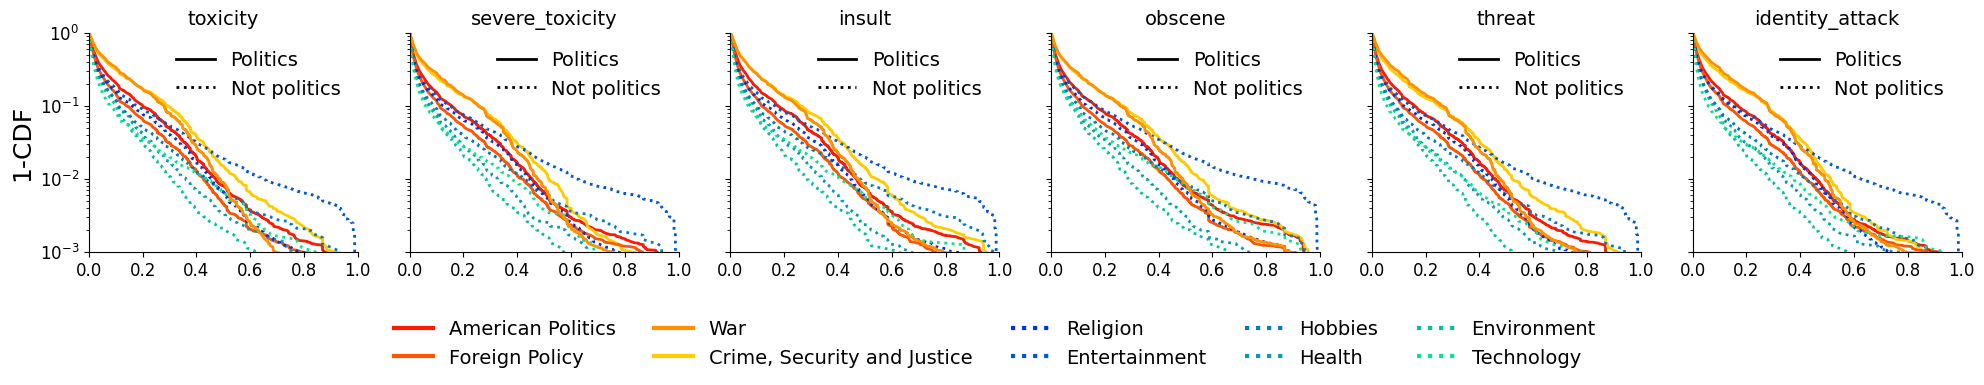

In [38]:
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
import numpy as np

cmap1 = plt.get_cmap('autumn')
cmap2 = plt.get_cmap('winter')

fig,ax=plt.subplots(ncols=6,sharey=True,sharex=True,figsize=(20,3))


norm1 = np.linspace(0.1, 0.8, len(politics))
norm2 = np.linspace(0.2, 0.9, len(non_politics))

color_map = {}

for g, n in zip(politics, norm1):
    color_map[g] = cmap1(n)

for g, n in zip(non_politics, norm2):
    color_map[g] = cmap2(n)

for idx,df_group in df.groupby('macrotopic_pred'):
    lines=[]
    for i,axis in enumerate(perspective_toxicity):
        linestyle='solid' if idx in politics else 'dotted'
        line=ax[i].plot(df_group[axis].sort_values(),1-np.linspace(0,1,len(df_group)),label=idx,c=color_map[idx],linewidth=2,linestyle=linestyle)
        lines.append(line)

legend_elements = [
    Line2D([0], [0], color='black', lw=2, linestyle='-',
           label='Politics'),
    Line2D([0], [0], color='black', lw=2, linestyle='dotted',
           label='Not politics')
]

for i,axis in enumerate(perspective_toxicity):
    ax[i].set_title(axis[len('perspective_'):],fontsize=14)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].tick_params(axis='both', labelsize=12)

    
    ax[i].legend( handles=legend_elements,
    fontsize=14,
    frameon=False,
    loc='upper right')


legend_elements = [
    Line2D([0], [0], color=color_map[idx], lw=3, linestyle='solid' if idx in politics else 'dotted',
           label=idx)
        for idx in politics+non_politics]


fig.legend(handles=legend_elements,
            loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.3)
)

ax[i].set_yscale('log')
ax[i].set_ylim(1e-3,1)
ax[i].set_xlim(0,1)

ax[0].set_ylabel('1-CDF',fontsize=18)


plt.tight_layout()

        

In [21]:
import pandas as pd 

df_all = pd.read_parquet("data/not_27.parquet")
df_all.head()

print(f"Número de linhas: {len(df)}")
df = df[df['macrotopic_pred'] != 'Others']
print(f"Número de linhas após filtrar 'Others': {len(df)}")
df = df[df['perspective_toxicity'].notna()]
print(f"Número de linhas após filtrar valores nulos em 'perspective_toxicity': {len(df)}")

df_all['macrotopic_pred'] = ['Crime, S. and J.' if topic == 'Crime, Security and Justice' else topic for topic in df_all['macrotopic_pred']]
df_all['macrotopic_pred'] = ['US Politics' if topic == 'American Politics' else topic for topic in df_all['macrotopic_pred']]

Número de linhas: 427960
Número de linhas após filtrar 'Others': 427960
Número de linhas após filtrar valores nulos em 'perspective_toxicity': 427959


In [12]:
politics = ['US Politics', 'War', 'Foreign Policy', 'Crime, S. and J.']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

palette_map = {}

for topic in non_politics:
    palette_map[topic] = "#577a8b"  

for topic in politics:
    palette_map[topic] = "#f4a04c"   
interest = [
    'War',
    'US Politics',
    'Foreign Policy',
    'Crime, S. and J.',
    'Health',
    'Religion',
    'Hobbies'
    ,"Technology"
    ,"Environment"
    ,"Entertainment"
]

macro_colors = {
    "US Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, S. and J.:     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
    , "Technology": "#890082"
    , "Environment": "#008000"
    , "Entertainment": "#FFD700"
}

df = df_all[df_all["macrotopic_pred"].isin(interest)]
len(df)

427960

In [22]:
from scipy.stats import mannwhitneyu
import numpy as np
toxicity_per_topic={}


for idx,df_group in df.groupby('macrotopic_pred'):
    toxicity_per_topic[idx]=df_group['perspective_toxicity']

In [23]:
comparison_per_topic={}
mannwithney_test_pairwise=np.zeros((len(toxicity_per_topic),len(toxicity_per_topic)))
ordered_topics=sorted(politics)+sorted(non_politics)
for i,idx1 in enumerate(ordered_topics):
    for j,idx2 in enumerate(ordered_topics):
        if idx1==idx2:
            continue
        test=mannwhitneyu(toxicity_per_topic[idx1].to_list(),toxicity_per_topic[idx2].to_list(),alternative='greater').pvalue
        if test<0.05/81: #Bonferroni Correction: every topic is compared with all the others:  
            print(idx1,idx2,test)
            mannwithney_test_pairwise[i,j]=1
mannwithney_test_pairwise=pd.DataFrame(mannwithney_test_pairwise,index=ordered_topics,columns=ordered_topics)
mannwithney_test_pairwise

Crime, S. and J. Foreign Policy 0.0
Crime, S. and J. US Politics 5.6937223312494755e-176
Crime, S. and J. Entertainment 0.0
Crime, S. and J. Environment 0.0
Crime, S. and J. Health 0.0
Crime, S. and J. Hobbies 0.0
Crime, S. and J. Religion 0.0
Crime, S. and J. Technology 0.0
Foreign Policy Environment 4.420228230774271e-60
Foreign Policy Health 1.7671294933674777e-46
Foreign Policy Hobbies 2.7919442348323967e-49
Foreign Policy Religion 1.4192620513589319e-12
Foreign Policy Technology 4.291561217362917e-178
US Politics Foreign Policy 1.1344066349051939e-131
US Politics Entertainment 2.965974402759845e-84
US Politics Environment 4.094143767634726e-226
US Politics Health 5.513530653609741e-193
US Politics Hobbies 4.3893841067424745e-248
US Politics Religion 2.0581602880892954e-295
US Politics Technology 0.0
War Crime, S. and J. 0.00012825247506006082
War Foreign Policy 0.0
War US Politics 0.0
War Entertainment 0.0
War Environment 0.0
War Health 0.0
War Hobbies 0.0
War Religion 0.0
War Tec

Entertainment Environment 1.2521499111361269e-117
Entertainment Health 3.683571775154101e-95
Entertainment Hobbies 4.9014415772592045e-120
Entertainment Religion 1.0794488576348282e-108
Entertainment Technology 8.614668643782082e-265
Environment Technology 3.5028430367757276e-34
Health Technology 2.5369661988786217e-37
Hobbies Environment 0.0002941801730680662
Hobbies Technology 1.2790582349655267e-58
Religion Environment 6.914808995294535e-38
Religion Health 4.220956809552818e-28
Religion Hobbies 2.2840281306115357e-27
Religion Technology 1.3180306292288613e-143


,"Crime, S. and J.",Foreign Policy,US Politics,War,Entertainment,Environment,Health,Hobbies,Religion,Technology
"Crime, S. and J.",0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Foreign Policy,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
US Politics,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
War,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Entertainment,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Environment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Hobbies,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Religion,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
Technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
ordered=mannwithney_test_pairwise.sum(axis=1).sort_values(ascending=False).index

In [25]:
ordered=['War', 'Crime, S. and J.', 'US Politics', 'Foreign Policy','Entertainment', 'Religion', 'Hobbies', 'Environment','Health', 'Technology']

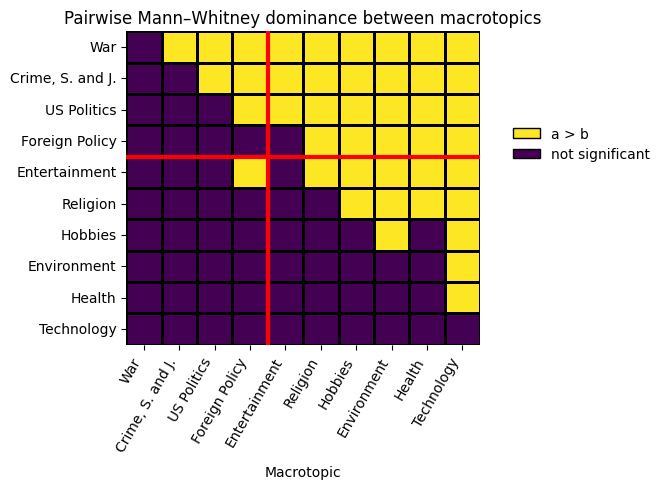

In [26]:
import seaborn as sns 
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(5,5))
cmap = plt.get_cmap('viridis')
sns.heatmap(mannwithney_test_pairwise.loc[ordered,ordered],linewidth=1,cbar=False,linecolor='k',ax=ax,cmap=cmap)
ax.vlines(4,0,10,linestyle='solid',color='red',linewidth=3)
ax.hlines(4,0,10,linestyle='solid',color='red',linewidth=3)
ax.set_title("Pairwise Mann–Whitney dominance between macrotopics", fontsize=12)
ax.set_xlabel("Macrotopic", labelpad=8)
plt.setp(ax.get_xticklabels(), rotation=60, ha='right')

plt.tight_layout()


from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=cmap(1.0), edgecolor='black',
          label='a > b'),
    Patch(facecolor=cmap(0), edgecolor='black',
          label='not significant')
]

fig.legend(
    handles=legend_elements,
    loc='center left',
    ncol=1,
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(1.01, 0.7)
)

# plt.subplots_adjust(bottom=0.18)

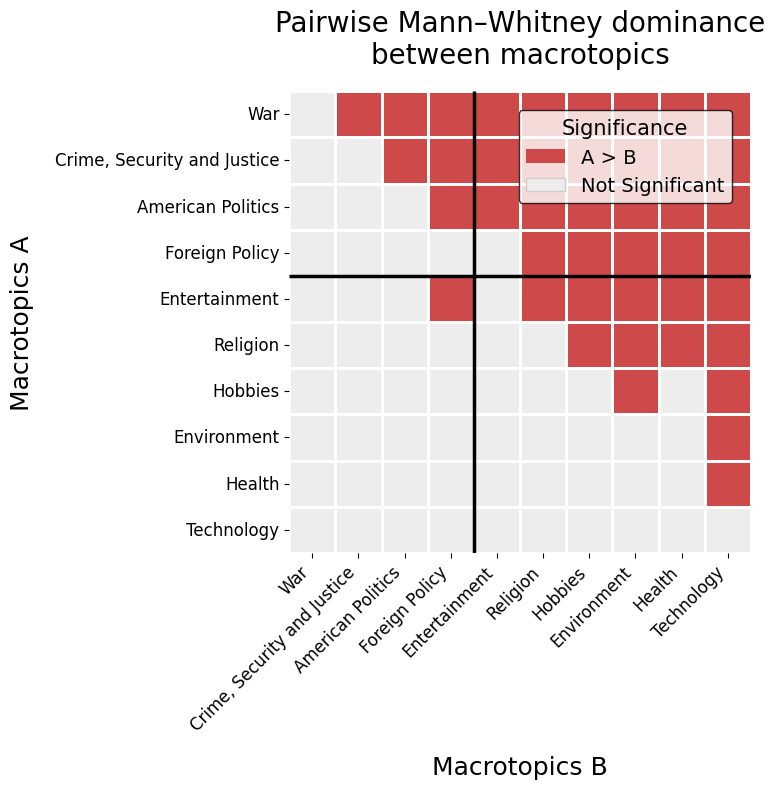

In [44]:
import seaborn as sns 
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

color_not_sig = '#EDEDED'
color_sig = '#CE4A4A'
custom_cmap = ListedColormap([color_not_sig, color_sig])

ffig, ax = plt.subplots(figsize=(8, 8)) 

# 2. Heatmap
sns.heatmap(
    mannwithney_test_pairwise.loc[ordered, ordered],
    linewidths=0.8,
    linecolor='white',
    cbar=False,
    square=True,      
    ax=ax,
    cmap=custom_cmap
)

# 3. Linhas Divisórias
ax.vlines(4, 0, 10, linestyle='solid', color='black', linewidth=2.5)
ax.hlines(4, 0, 10, linestyle='solid', color='black', linewidth=2.5)

# Títulos e Labels
ax.set_title("Pairwise Mann–Whitney dominance\nbetween macrotopics", fontsize=20, pad=20)
ax.set_xlabel("Macrotopics B", labelpad=15, fontsize=18)
ax.set_ylabel("Macrotopics A", labelpad=15, fontsize=18)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=12)

# 4. Legenda "Dentro" ou ao lado da matriz
legend_elements = [
    Patch(facecolor=color_sig, label='A > B'),
    Patch(facecolor=color_not_sig, edgecolor='#CCCCCC', label='Not Significant')
]

# loc='upper left' com bbox_to_anchor=(1.02, 1) coloca a legenda FORA, à direita.
# loc='upper right' com bbox_to_anchor=(0.98, 0.98) coloca a legenda DENTRO, no canto superior direito.
ax.legend(
    handles=legend_elements,
    loc='upper right', 
    bbox_to_anchor=(0.98, 0.98), # Coordenadas internas (x, y) de 0 a 1
    ncol=1,
    frameon=True,       # Moldura ajuda a destacar se estiver sobreposta
    facecolor='white',  # Fundo branco para a legenda não ficar transparente
    edgecolor='black',
    fontsize=14,
    title="Significance",
    title_fontsize=15
)

plt.savefig("gráficos/mannwhitney_pairwise_heatmap", bbox_inches='tight')

plt.tight_layout()
plt.show()

In [45]:
interest = [
    'War',
    'American Politics',
    'Foreign Policy',
    'Crime, Security and Justice',
    'Health',
    'Religion',
    'Hobbies'
    #,"Technology"
    #,"Environment"
    #,"Entertainment"
]

In [46]:
df_resumo = df_resumo[df_resumo['macrotopic_pred'].isin(interest)].copy()
df_resumo['Politics']=df_resumo['macrotopic_pred'].apply(lambda x: x in politics)
df_politics=df_resumo[df_resumo['Politics']]
df_non_politics=df_resumo[~df_resumo['Politics']]

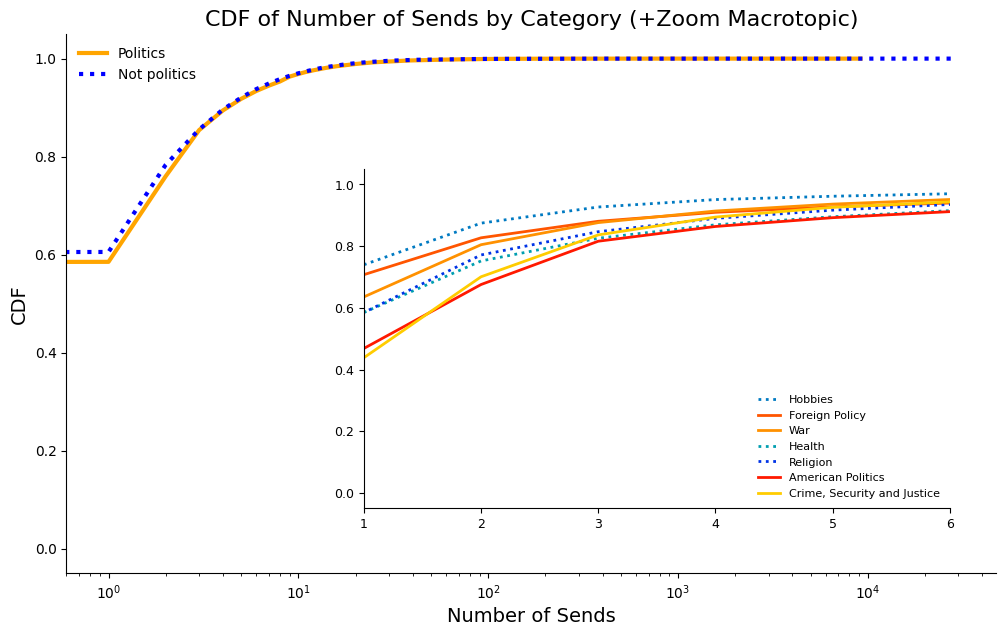

In [47]:
fig, ax = plt.subplots(figsize=(12, 7))

value = 'send_count'

# Politics
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])

ax.plot(xs, y, 'orange', linestyle='solid', linewidth=3, label='Politics')

# Not politics
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])

ax.plot(xs, y, 'blue', linestyle='dotted', linewidth=3, label='Not politics')

ax.set_xscale('log')

ax.set_xlabel('Number of Sends', fontsize=14)
ax.set_ylabel('CDF', fontsize=14)

ax.legend(loc='upper left', frameon=False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# =======================
# INSET – CDF por macrotopic 
# =======================

axin = ax.inset_axes([0.32, 0.12, 0.63, 0.63])

ponto_ordenacao = 1

ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x <= ponto_ordenacao).mean()
)

# do maior para o menor (quem tem mais massa em x=1 aparece primeiro)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:

    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([(x_sorted <= v).sum() / n for v in xs])

    linestyle = 'solid' if idx in politics else 'dotted'
    axin.plot(
        xs,
        y,
        color=color_map[idx],
        linewidth=2,
        linestyle=linestyle,
        label=idx
    )

axin.set_xlim(1, 6)

axin.set_xlabel('')
axin.set_ylabel('')
axin.tick_params(labelsize=9)

axin.spines['right'].set_visible(False)
axin.spines['top'].set_visible(False)

axin.legend(
    fontsize=8,
    frameon=False,
    loc='lower right'
)

ax.set_title('CDF of Number of Sends by Category (+Zoom Macrotopic)', fontsize=16)

plt.show()

In [48]:
df_resumo = df_resumo[df_resumo['send_count'] > 1].copy()
df_resumo['Politics']=df_resumo['macrotopic_pred'].apply(lambda x: x in politics)
df_politics=df_resumo[df_resumo['Politics']]
df_non_politics=df_resumo[~df_resumo['Politics']]

In [49]:
df_politics

,video_id,lifetime,send_count,folder,transfer_time,macrotopic_pred,perspective_toxicity,Politics
4,--0WrRVhu20,1.0,10,9,0.0,"Crime, Security and Justice",0.008402,True
13,--33obumD9M,1.0,2,2,0.0,American Politics,0.023995,True
14,--3B0KgX-Ug,1.0,3,2,0.0,War,0.218660,True
19,--5SXYOKgrQ,5.0,4,2,0.0,War,0.396442,True
30,--APBdKjb6Q,1.0,2,2,744.0,"Crime, Security and Justice",0.061102,True
...,...,...,...,...,...,...,...,...
427923,zzepkf9iUTk,5.0,3,3,0.0,American Politics,0.085828,True
427929,zzgEpJE2vzA,1.0,2,2,0.0,Foreign Policy,0.001841,True
427932,zzjlHMFkRdk,1.0,4,4,0.0,War,0.022315,True
427934,zzkiOoXcuxI,1.0,2,2,1.0,Foreign Policy,0.015341,True


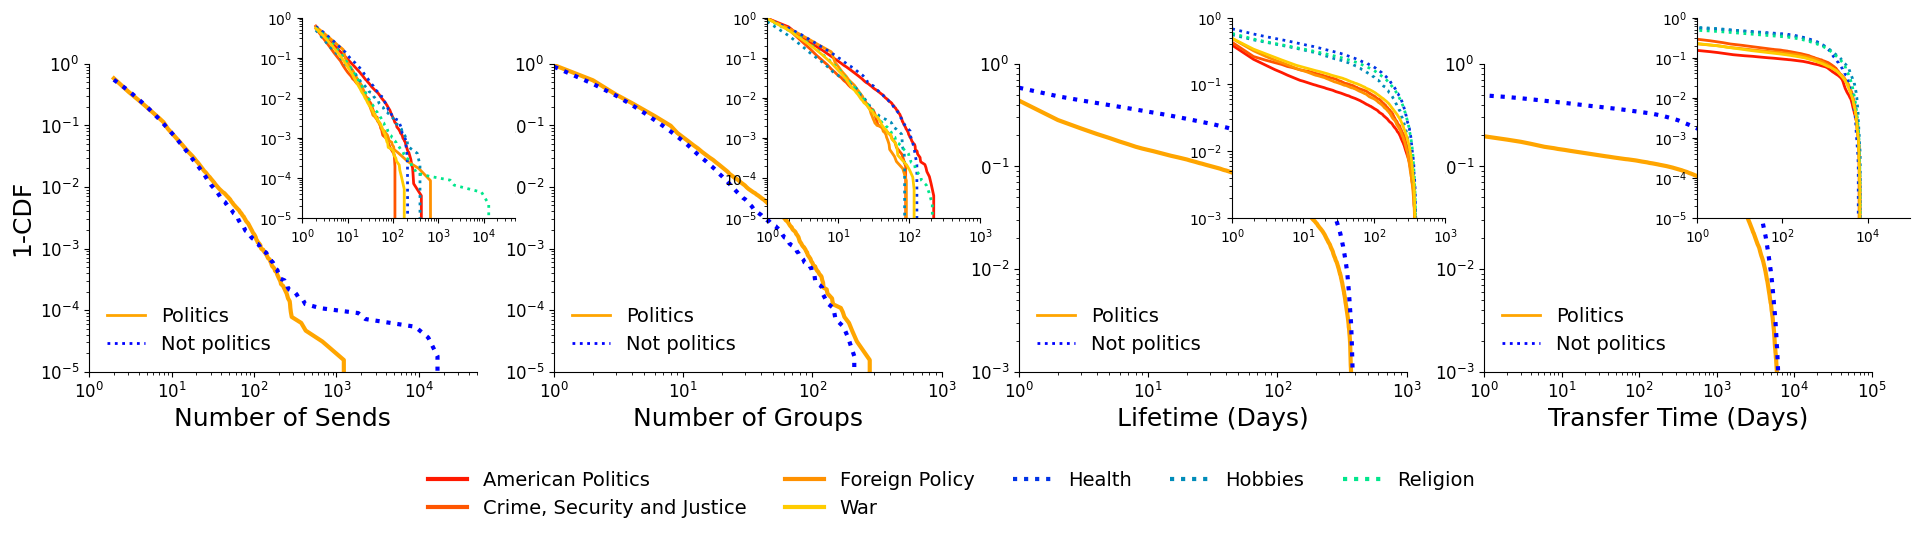

In [50]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from collections import Counter

fig, axs = plt.subplots(figsize=(23, 4),ncols=4)

to_plot=['send_count','folder','lifetime','transfer_time']

cmap1 = plt.get_cmap('autumn')
cmap2 = plt.get_cmap('winter')

macros_used = sorted(df_resumo['macrotopic_pred'].unique())
color_map = {}

for g in macros_used:
    if g in politics:
        color_map[g] = cmap1(
            np.linspace(0.1, 0.8, sum(m in politics for m in macros_used))[ 
                [m for m in macros_used if m in politics].index(g)
            ]
        )
    else:
        color_map[g] = cmap2(
            np.linspace(0.2, 0.9, sum(m not in politics for m in macros_used))[ 
                [m for m in macros_used if m not in politics].index(g)
            ]
        )

axins=[]

for ax,value in zip(axs,to_plot):
    
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs
            , y
            ,'orange'
            ,linestyle='solid'
            ,linewidth=3)
    
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs 
            , y
            ,'blue'
            ,linestyle='dotted'
            ,linewidth=3)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    legend_elements = [
        Line2D([0], [0], color='orange', lw=2, linestyle='-',
               label='Politics'),
        Line2D([0], [0], color='blue', lw=2, linestyle='dotted',
               label='Not politics')
    ]
    
     
    ax.legend( handles=legend_elements,
        fontsize=14,
        frameon=False,
        loc='lower left')

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    axin = inset_axes(
        ax,
        width="55%",     # dimensione relativa
        height="65%",
        loc='upper right',
        borderpad=0,
        bbox_to_anchor=(0.1, 0.15, 1, 1),  # x > 1 
        bbox_transform=ax.transAxes
    )

    for idx,df_group in df_resumo.groupby('macrotopic_pred'):
        linestyle = 'solid' if idx in politics else 'dotted'

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)
        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
        line = axin.plot(xs,
                        y,
                        label=idx,
                        c=color_map[idx],
                        linewidth=2,
                        linestyle=linestyle)

        lines.append(line)

        
    axin.set_xscale('log')
    axin.set_yscale('log')

    axin.spines['right'].set_visible(False)
    axin.spines['top'].set_visible(False)
    
    axins.append(axin)

ordered_macros = (
    [m for m in macros_used if m in politics] +
    [m for m in macros_used if m not in politics]
)
legend_elements = [
    Line2D([0], [0], color=color_map[idx], lw=3, linestyle='solid' if idx in politics else 'dotted',
           label=idx)
        for idx in ordered_macros]

axs[0].set_xlim(1,50000)
axs[0].set_ylim(1e-5,1)
axs[0].set_xlabel('Number of Sends',fontsize=18)
axs[0].set_ylabel('1-CDF',fontsize=18)
axins[0].set_xlim(1,50000)
axins[0].set_ylim(1e-5,1)


axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-5,1)
axs[1].set_xlabel('Number of Groups',fontsize=18)
axins[1].set_xlim(1,1000)
axins[1].set_ylim(1e-5,1)


axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-3,1)
axs[2].set_xlabel('Lifetime (Days)',fontsize=18)

axins[2].set_xlim(1,1000)
axins[2].set_ylim(1e-3,1)

axs[3].set_xlim(1, 100000) 
axs[3].set_ylim(1e-3, 1)
axs[3].set_xlabel('Transfer Time (Days)',fontsize=18)
axins[3].set_xlim(1,100000)
axins[3].set_ylim(1e-5,1)

fig.legend(handles=legend_elements,
            loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.3)
)


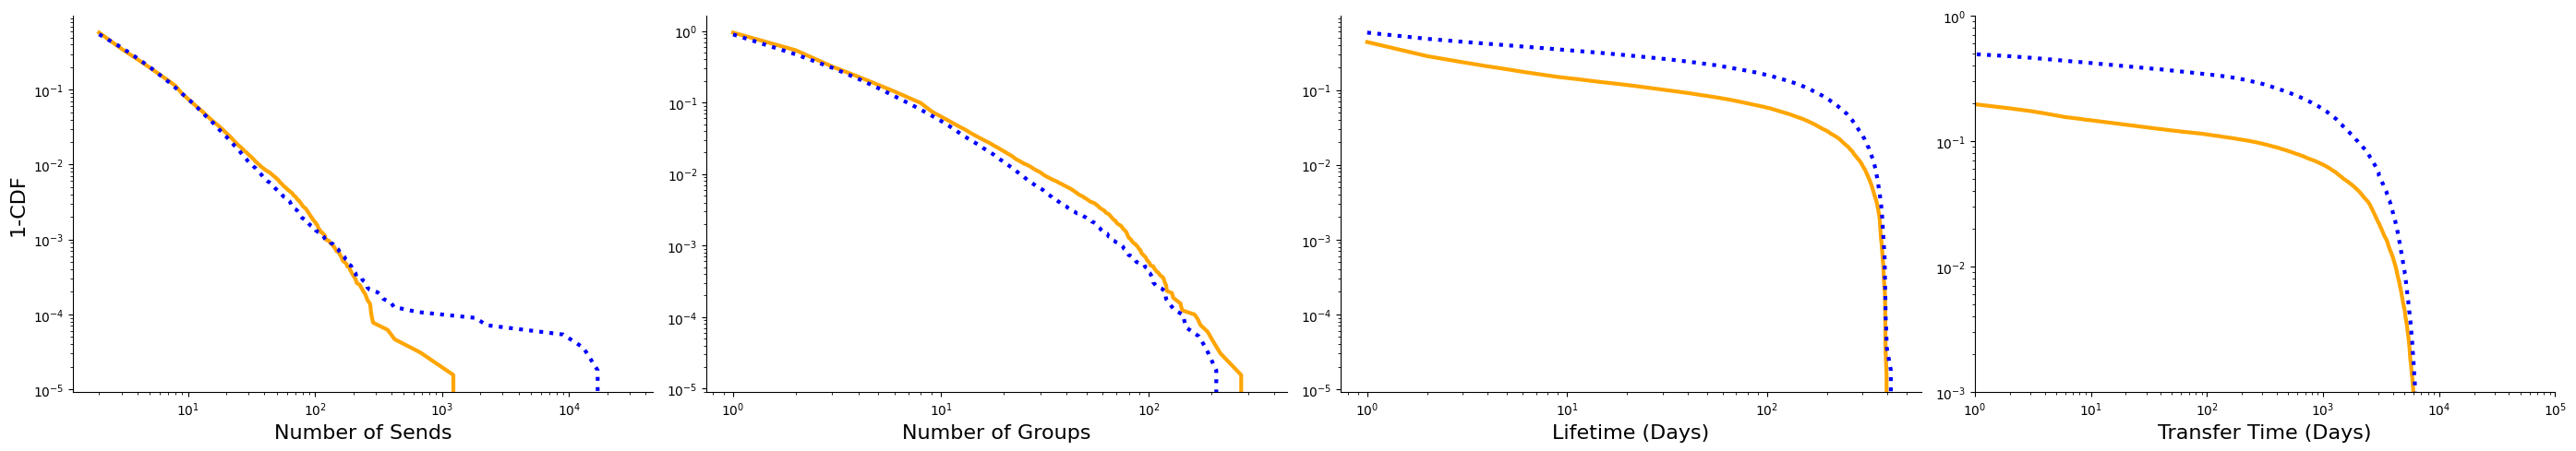

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. Preparação dos dados (Garante que os dias sejam inteiros e positivos)
#df_resumo['transfer_days'] = df_resumo['transfer_time'].dt.days.clip(lower=0)

# 2. Configuração da figura (Adicionando uma coluna para o novo gráfico)
fig, axs = plt.subplots(figsize=(28, 5), ncols=4) # Aumentei largura para 4 colunas
to_plot = ['send_count', 'folder', 'lifetime', 'transfer_time']
labels = ['Number of Sends', 'Number of Groups', 'Lifetime (Days)', 'Transfer Time (Days)']

# Reaproveitando sua lógica de cores (color_map deve estar definido como no seu código)

for ax, value, label in zip(axs, to_plot, labels):
    
    # --- Curva Geral: Politics ---
    df_p = df_resumo[df_resumo['macrotopic_pred'].isin(politics)]
    x_sorted = np.sort(df_p[value].dropna().values)
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (np.searchsorted(x_sorted, v, side='right') / n) for v in xs])
    ax.plot(xs, y, 'orange', linestyle='solid', linewidth=3, label='Politics')
    
    # --- Curva Geral: Non-Politics ---
    df_np = df_resumo[~df_resumo['macrotopic_pred'].isin(politics)]
    x_sorted = np.sort(df_np[value].dropna().values)
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (np.searchsorted(x_sorted, v, side='right') / n) for v in xs])
    ax.plot(xs, y, 'blue', linestyle='dotted', linewidth=3, label='Not politics')

    # --- Configurações de Eixo ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(label, fontsize=16)
    if ax == axs[0]: ax.set_ylabel('1-CDF', fontsize=16)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Ajuste específico de limites para o gráfico de Transfer Time (axs[3])
axs[3].set_xlim(1, 100000) # Ajuste conforme a distribuição dos seus dados
axs[3].set_ylim(1e-3, 1)

plt.tight_layout()
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def fit_line_with_ci(ax, x, y, ci=95, n_boot=1000, x_grid=None, **line_kwargs):
    # pulizia
    m = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[m]
    y = np.asarray(y)[m]

    # griglia x
    if x_grid is None:
        x_grid = np.linspace(x.min(), x.max(), 200)

    # fit "centrale" (OLS)
    b1, b0 = np.polyfit(x, y, 1)          # y = b1*x + b0
    y_hat = b1 * x_grid + b0

    # bootstrap della retta
    rng = np.random.default_rng(0)
    preds = np.empty((n_boot, len(x_grid)))

    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)       # resample con replacement
        xb = x[idx]
        yb = y[idx]
        bb1, bb0 = np.polyfit(xb, yb, 1)
        preds[i] = bb1 * x_grid + bb0

    lo = np.percentile(preds, (100 - ci) / 2, axis=0)
    hi = np.percentile(preds, 100 - (100 - ci) / 2, axis=0)

    # plot shadow + linea
    ax.fill_between(x_grid, lo, hi, alpha=0.2)
    ax.plot(x_grid, y_hat, **line_kwargs)

    return b1, b0


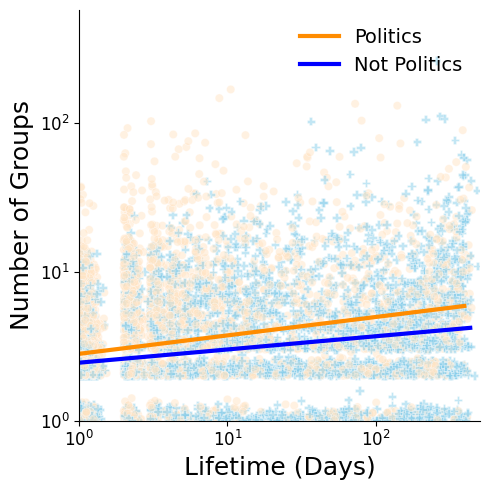

In [53]:
import seaborn as sns

combinatios = [['lifetime', 'folder'],['lifetime']]

sigma = 0.05
df_resumo_logged=np.log10(df_resumo[['lifetime','folder']]).iloc[::10]
df_politics_logged=np.log10(df_politics[['lifetime','folder']])
df_non_politics_logged=np.log10(df_non_politics[['lifetime','folder']])

df_resumo_logged+= np.abs(np.random.normal(0, sigma, size=df_resumo_logged.shape))


fig,ax=plt.subplots(figsize=(5,5))

sns.scatterplot(df_resumo_logged,x='lifetime',y='folder',
                hue=df_resumo['Politics'].iloc[::10],
                style=df_resumo['Politics'].iloc[::10],
                hue_order=[False, True],
                style_order=[False, True],
                ax=ax,
                alpha=0.5,
                sizes=1,
                palette=['skyblue','bisque'],
                markers={True:'o',False:'P'},legend=False)

fit_line_with_ci(
    ax,
    df_politics_logged['lifetime'].to_numpy(),
    df_politics_logged['folder'].to_numpy(),
    ci=99,
    n_boot=1000,
    color='darkorange',   # linea arancione
    lw=3              # linewidth=3
)

fit_line_with_ci(
    ax,
    df_non_politics_logged['lifetime'].to_numpy(),
    df_non_politics_logged['folder'].to_numpy(),
    ci=99,
    n_boot=1000,
    color='blue',   # linea arancione
    lw=3              # linewidth=3
)



ax.set_yticks(range(4),[rf'$10^{i}$' for i in range(4)])
ax.set_xticks(range(4),[rf'$10^{i}$' for i in range(4)])
ax.set_ylim(-0,2.761186)
ax.set_xlim(-0,2.704428)

legend_elements = [
    Line2D([0], [0], color='darkorange', lw=3, linestyle='solid',
           label='Politics'),
     Line2D([0], [0], color='blue', lw=3, linestyle='solid',
           label='Not Politics')]

ax.legend( handles=legend_elements,
    fontsize=14,
    frameon=False,
    loc='upper right')

ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel('Lifetime (Days)',fontsize=18)
ax.set_ylabel('Number of Groups',fontsize=18)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

plt.show()


/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


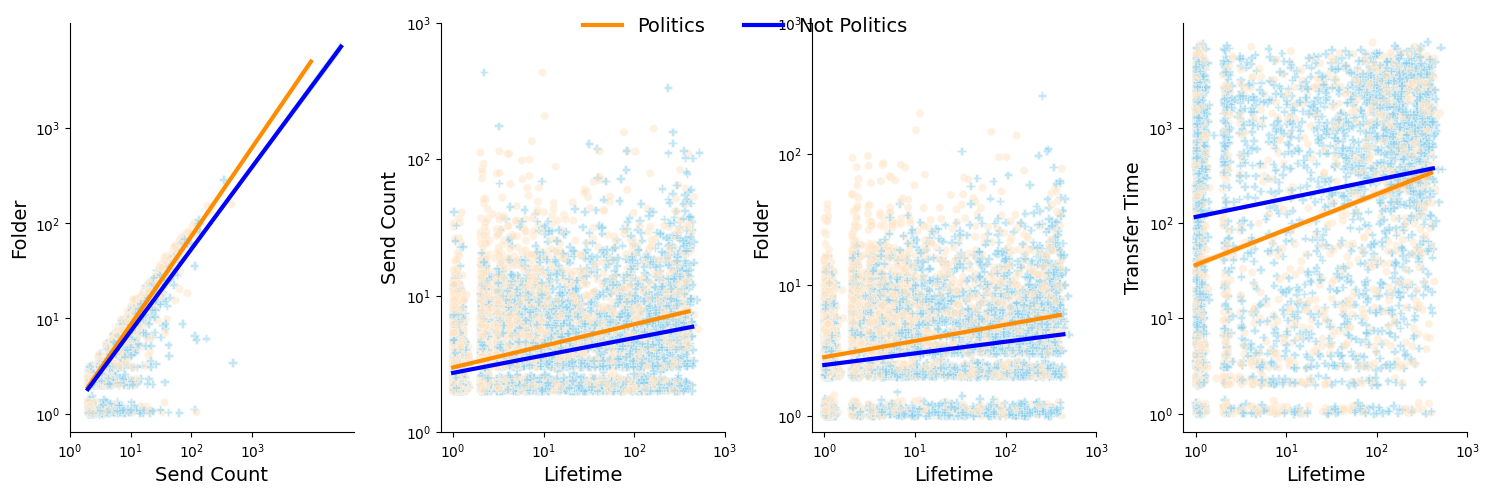

In [61]:
pairs = [
    ('send_count', 'folder'),
    ('lifetime', 'send_count'),
    ('lifetime', 'folder'),
    ('lifetime', 'transfer_time'),
]

sigma = 0.05

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):

    df_resumo_logged = np.log10(df_resumo[[xcol, ycol]]).iloc[::10]
    df_politics_logged = np.log10(df_politics[[xcol, ycol]])
    df_non_politics_logged = np.log10(df_non_politics[[xcol, ycol]])

    # mesmo jitter que você usa
    df_resumo_logged += np.abs(
        np.random.normal(0, sigma, size=df_resumo_logged.shape)
    )

    sns.scatterplot(
        data=df_resumo_logged,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::10],
        style=df_resumo['Politics'].iloc[::10],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.5,
        sizes=1,
        palette=['skyblue','bisque'],
        markers={True:'o', False:'P'},
        legend=False
    )

    fit_line_with_ci(
        ax,
        df_politics_logged[xcol].to_numpy(),
        df_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='darkorange',
        lw=3
    )

    fit_line_with_ci(
        ax,
        df_non_politics_logged[xcol].to_numpy(),
        df_non_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='blue',
        lw=3
    )

    ax.set_xticks(range(4), [rf'$10^{i}$' for i in range(4)])
    ax.set_yticks(range(4), [rf'$10^{i}$' for i in range(4)])

    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=14)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# legenda única
legend_elements = [
    Line2D([0], [0], color='darkorange', lw=3, label='Politics'),
    Line2D([0], [0], color='blue', lw=3, label='Not Politics')
]

fig.legend(
    handles=legend_elements,
    fontsize=14,
    frameon=False,
    loc='upper center',
    ncol=2
)

plt.tight_layout()
plt.show()


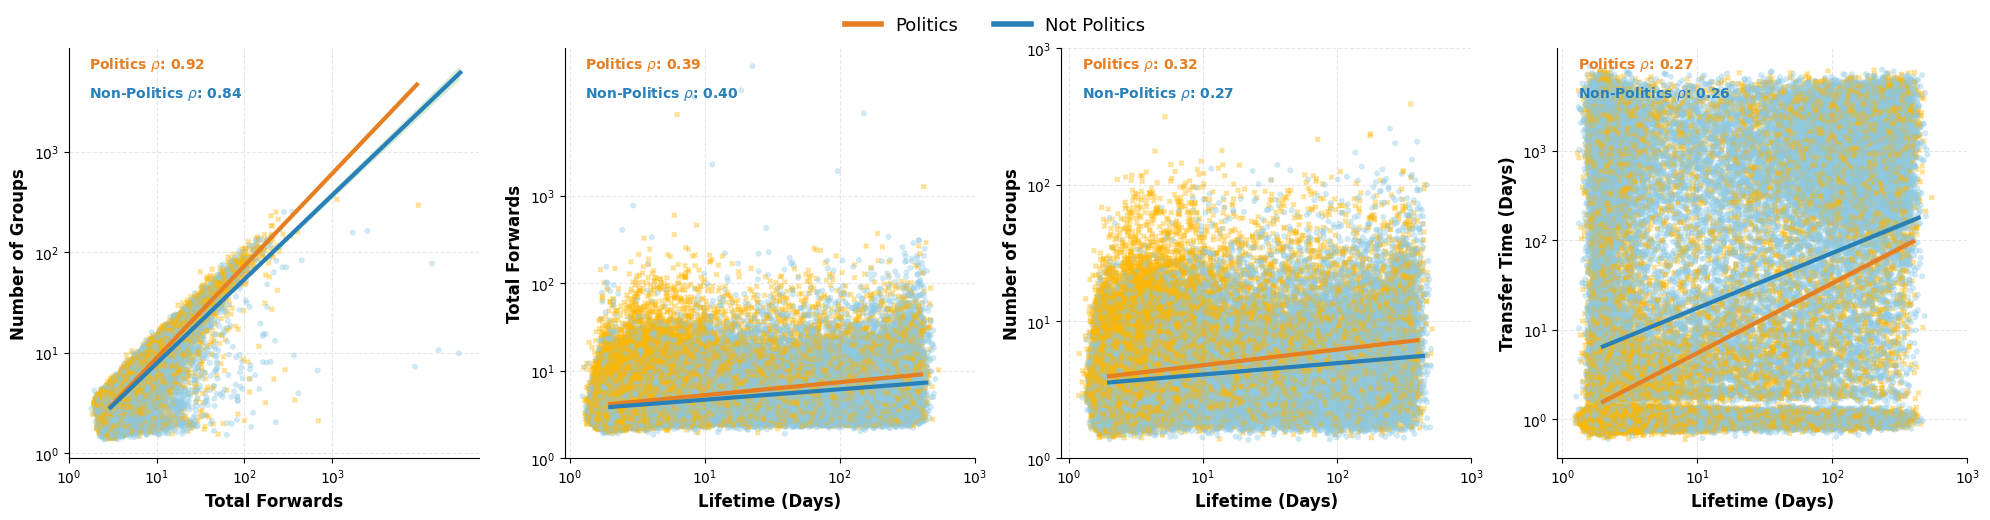

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# Dicionário para nomes mais bonitos nos eixos
display_names = {
    'send_count': 'Total Forwards',
    'folder': 'Number of Groups',
    'lifetime': 'Lifetime (Days)',
    'transfer_time': 'Transfer Time (Days)'
}

pairs = [
    ('send_count', 'folder'),
    ('lifetime', 'send_count'),
    ('lifetime', 'folder'),
    ('lifetime', 'transfer_time'),
]

sigma = 0.05
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):
    # 1. Preparação dos dados com log10(x+1) para evitar log(0)
    # Selecionando apenas as colunas necessárias para evitar overhead
    data_subset = df_resumo[[xcol, ycol, 'Politics']].dropna()
    
    # Aplicando log e jitter para a visualização dos pontos
    x_logged = np.log10(data_subset[xcol] + 1) 
    y_logged = np.log10(data_subset[ycol] + 1)
    
    # Scatter plot amostrado para não poluir
    #idx = np.random.choice(data_subset.index, size=min(len(data_subset), 2000), replace=False)
    idx = data_subset.index  # Usar todos os dados para evitar amostragem
    
    sns.scatterplot(
        x=x_logged[idx] + np.random.normal(0, sigma, size=len(idx)),
        y=y_logged[idx] + np.random.normal(0, sigma, size=len(idx)),
        hue=data_subset.loc[idx, 'Politics'],
        style=data_subset.loc[idx, 'Politics'],
        hue_order=[False, True],
        palette=['#8ecae6', '#ffb703'], # Cores mais modernas
        alpha=0.4,
        edgecolor=None,
        s=15,
        ax=ax,
        legend=False
    )

    # 2. Regressões (Usando os dados completos, não apenas a amostra)
    for is_politics, color, label in [(True, '#e67e22', 'Politics'), (False, '#2980b9', 'Non-Politics')]:
        mask = data_subset['Politics'] == is_politics
        curr_x = np.log10(data_subset.loc[mask, xcol] + 1)
        curr_y = np.log10(data_subset.loc[mask, ycol] + 1)
        
        # Sua função original de fit
        fit_line_with_ci(ax, curr_x.to_numpy(), curr_y.to_numpy(), 
                         ci=99, n_boot=1000, color=color, lw=3)
        
        # 3. Adicionar Correlação de Spearman no topo do gráfico
        rho, _ = spearmanr(data_subset.loc[mask, xcol], data_subset.loc[mask, ycol])
        y_pos = 0.95 if is_politics else 0.88
        ax.text(0.05, y_pos, f'{label} $\\rho$: {rho:.2f}', 
                transform=ax.transAxes, color=color, fontsize=10, fontweight='bold')

    # 4. Estética dos Eixos
    ax.set_xlabel(display_names.get(xcol, xcol), fontsize=12, fontweight='bold')
    ax.set_ylabel(display_names.get(ycol, ycol), fontsize=12, fontweight='bold')
    
    # Formatação dos ticks para escala log (1, 10, 100...)
    ticks = [0, 1, 2, 3]
    tick_labels = ['$10^0$', '$10^1$', '$10^2$', '$10^3$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)

# Legenda centralizada e elegante
legend_elements = [
    Line2D([0], [0], color='#e67e22', lw=4, label='Politics'),
    Line2D([0], [0], color='#2980b9', lw=4, label='Not Politics')
]

fig.legend(
    handles=legend_elements,
    fontsize=13,
    frameon=False,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout()
plt.show()

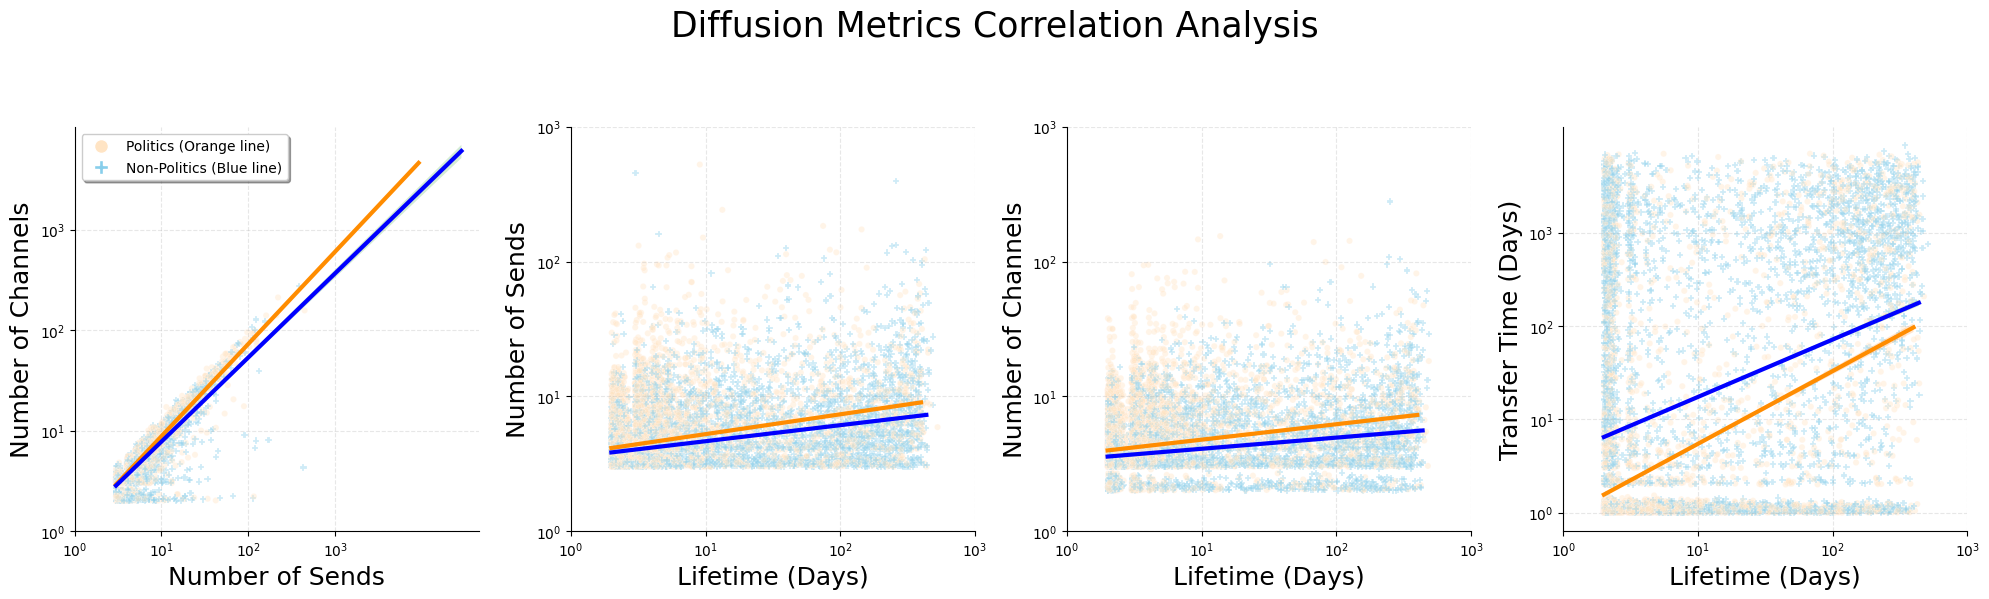

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Configurações de estilo
sigma = 0.05
# Ajustamos o figsize para (20, 5) para que cada um dos 4 plots tenha aprox. 5x5 (quadrado)
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharex=False, sharey=False)

fig.suptitle('Diffusion Metrics Correlation Analysis', fontsize=25, y=1.05)

labels_map = {
    'send_count': 'Number of Sends',
    'folder': 'Number of Channels',
    'lifetime': 'Lifetime (Days)',
    'transfer_time': 'Transfer Time (Days)'
}

pairs = [
    ('send_count', 'folder'),
    ('lifetime', 'send_count'),
    ('lifetime', 'folder'),
    ('lifetime', 'transfer_time'),
]

for i, (ax, (xcol, ycol)) in enumerate(zip(axes, pairs)):
    # Preparação dos dados com log10(x+1) para não perder os zeros
    df_resumo_logged = np.log10(df_resumo[[xcol, ycol]] + 1).iloc[::10]
    df_politics_logged = np.log10(df_politics[[xcol, ycol]] + 1)
    df_non_politics_logged = np.log10(df_non_politics[[xcol, ycol]] + 1)

    # Adicionando jitter
    df_resumo_logged += np.abs(np.random.normal(0, sigma, size=df_resumo_logged.shape))

    # Scatter plot
    sns.scatterplot(
        data=df_resumo_logged,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::10],
        style=df_resumo['Politics'].iloc[::10],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.4,
        palette=['skyblue', 'bisque'],
        markers={True: 'o', False: 'P'},
        legend=False,
        s=20 # Aumentado levemente para visibilidade
    )

    # Regressões
    fit_line_with_ci(ax, df_politics_logged[xcol].to_numpy(), df_politics_logged[ycol].to_numpy(),
                     ci=99, n_boot=1000, color='darkorange', lw=3)
    
    fit_line_with_ci(ax, df_non_politics_logged[xcol].to_numpy(), df_non_politics_logged[ycol].to_numpy(),
                     ci=99, n_boot=1000, color='blue', lw=3)

    # Deixando o plot quadrado (Aspect Ratio 1:1)
    ax.set_box_aspect(1)

    # Eixos e Ticks
    ax.set_xticks(range(4))
    ax.set_xticklabels([rf'$10^{{{j}}}$' for j in range(4)])
    ax.set_yticks(range(4))
    ax.set_yticklabels([rf'$10^{{{j}}}$' for j in range(4)])

    ax.set_xlabel(labels_map.get(xcol, xcol), fontsize=18)
    ax.set_ylabel(labels_map.get(ycol, ycol), fontsize=18)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Adicionando a legenda apenas no primeiro gráfico (canto superior esquerdo)
    if i == 0:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='bisque', markersize=10, label='Politics (Orange line)'),
            Line2D([0], [0], marker='P', color='w', markerfacecolor='skyblue', markersize=10, label='Non-Politics (Blue line)')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("gráficos/correlation_analysis.png", bbox_inches='tight')
plt.show()

In [ ]:
df.head()

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_insult,perspective_severe_toxicity,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,...,0.021224,0.005379,0.008414,0.123468,0.049762,0.029415,Religion,0.000,1.0,1
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'id': 449843, 'folder': 'channel_1571505334'...",0.002710,0.000104,...,0.019419,0.005112,0.001093,0.075294,0.017666,0.022509,Religion,0.005,2.0,5
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'id': 104116, 'folder': 'channel_1438734111'...",0.001515,0.000100,...,0.027841,0.004921,0.002368,0.111507,0.019375,0.028207,Environment,0.000,2.0,2
5,r-5_TrtuqHc,christian movie gabriel revival inspire family...,Rehoboth Revival Church Tamil U.K,2020-05-03T20:05:03Z,12197764.0,136390.0,8317.0,"[{'id': 523602, 'folder': 'channel_1593523413'...",0.008134,0.000103,...,0.036105,0.009384,0.006484,0.153245,0.061585,0.017847,Entertainment,0.000,243.0,2
6,QKXr7N9c6Yo,roman islamic antichrist sonia azam explore bi...,Armageddon News,2021-10-11T16:36:04Z,2249.0,107.0,75.0,"[{'id': 28786, 'folder': 'channel_2165208912',...",0.003288,0.000109,...,0.378466,0.169603,0.003076,0.453968,0.460282,0.119229,Religion,0.000,1.0,1


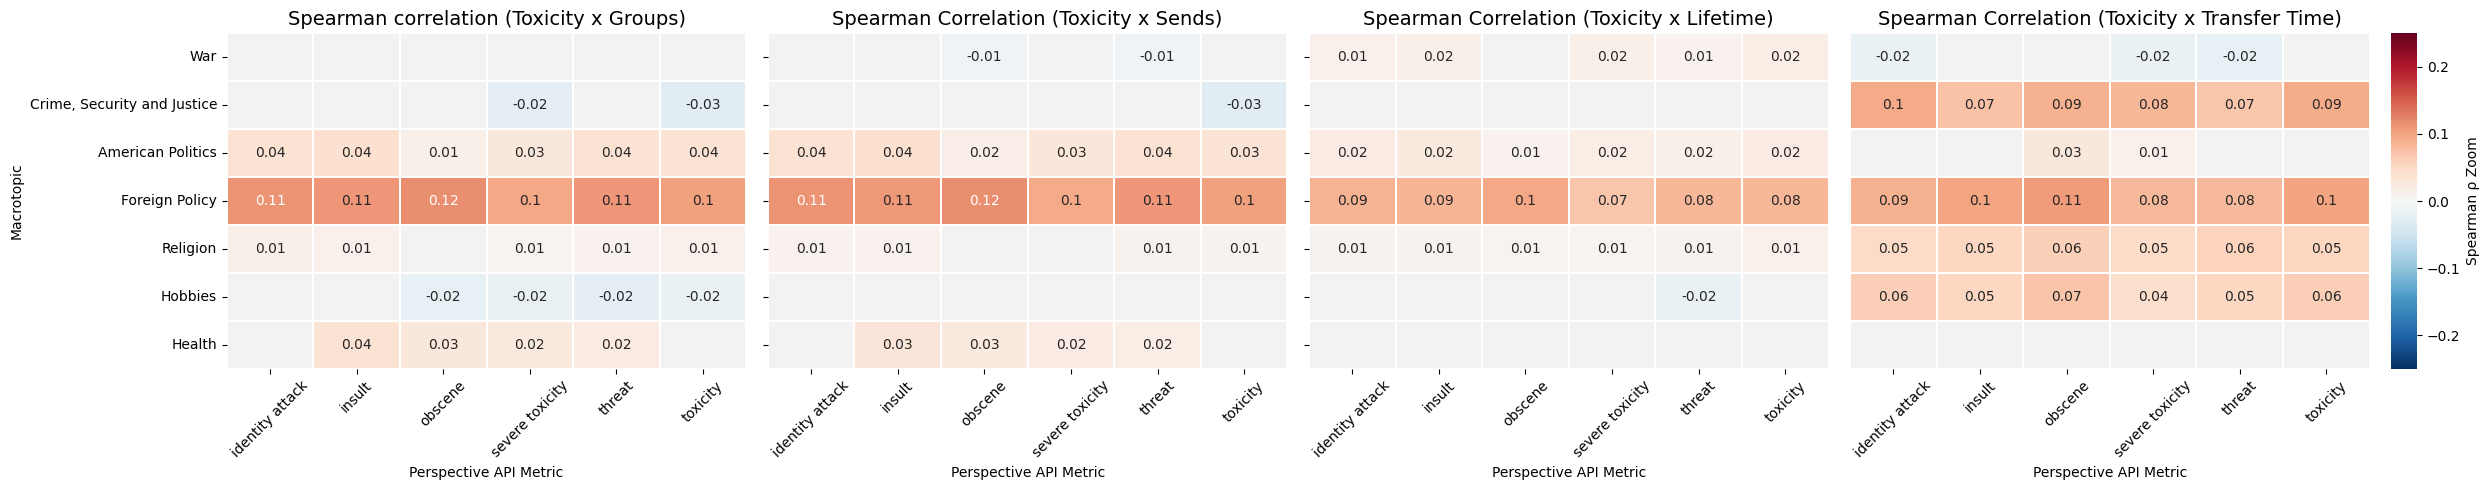

In [55]:
from scipy.stats import spearmanr

def spearman_by_topic(df_topic, col_pivo ,cols):
    results = {}

    for col in cols:
        tmp = df_topic[[col_pivo, col]].dropna()

        rho, p = spearmanr(tmp[col_pivo], tmp[col])

        results[col] = {
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        }

    return results

def apply_spearman_correlation(df, col_pivo, cols):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        topic_results = spearman_by_topic(df_topic, col_pivo, cols)

        for metric, values in topic_results.items():
            all_results.append({
                'macrotopic_pred': topic,
                'metric': metric,
                'spearman_rho': values['spearman_rho'],
                'p_value': values['p_value'], 
                'n': values['n']
            })

    results_df = pd.DataFrame(all_results)

    # Tabela 1: Força da Correlação (Rho)
    pivot_rho = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='spearman_rho'
    ).sort_index()
    
    # Tabela 2: Significância Estatística (P-valor)
    pivot_p = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='p_value'
    ).sort_index()

    return pivot_rho, pivot_p

def plot_heatmap(
    pivot, title, p_values=None, vmin=-1, vmax=1,
    xlabel="Perspective API Metric", ylabel="Macrotopic",
    yticks=True, xticks=True, cbar_label="Spearman ρ",
    ax=None, cbar=True, cbar_ax=None
):

    pivot_plot = pivot.copy()
    pivot_plot.columns = [
        col.replace('perspective_', '').replace('_', ' ')
        for col in pivot_plot.columns
    ]

    mask = None
    annot_data = True
    fmt_str = ".2f"

    if p_values is not None:
        p_val_plot = p_values.copy()
        p_val_plot.columns = pivot_plot.columns

        # p >= 0.05 será mascarado (inclui o caso p == 0.05)
        mask = p_val_plot >= 0.05

        # anotação só com o valor (sem asterisco)
        annot_data = pivot_plot.round(2).astype(str)

        # remove texto das células mascaradas
        for r in pivot_plot.index:
            for c in pivot_plot.columns:
                if mask.loc[r, c]:
                    annot_data.loc[r, c] = ""

        fmt_str = ""

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # colormap com cor para células mascaradas
    cmap = sns.color_palette("RdBu_r", as_cmap=True)
    cmap.set_bad(color="#f2f2f2")

    sns.heatmap(
        pivot_plot,
        annot=annot_data,
        fmt=fmt_str,
        cmap=cmap,
        center=0,
        vmin=vmin,
        vmax=vmax,
        mask=mask,
        linewidths=0.01,
        yticklabels=yticks,
        xticklabels=xticks,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={"label": cbar_label}
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)

    if ax is None:
        plt.tight_layout()
        plt.show()

df_analise_canal = df_complete.groupby("video_id").agg({
    "folder": "nunique",
    "perspective_toxicity": "mean",
    "perspective_identity_attack": "mean",
    "perspective_insult": "mean",
    "perspective_obscene": "mean",
    "perspective_severe_toxicity": "mean",
    "perspective_threat": "mean",
    "macrotopic_pred": "first",
}).reset_index()

ordem_desejada = [
    "War",
    "Crime, Security and Justice",
    "American Politics",
    "Foreign Policy",
    "Religion",
    "Hobbies",
    "Health"
]

tox_cols = [
    'perspective_toxicity',
    'perspective_severe_toxicity',
    'perspective_insult',
    'perspective_obscene',
    'perspective_threat',
    'perspective_identity_attack'
]

# Cria 4 colunas: 3 para gráficos e 1 para a barra de cores
fig, axs = plt.subplots(1, 5, figsize=(25, 5), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.05]})

# --- GRÁFICO 1: GROUPS (Grupos/Canais) - Eixo 0 ---
rho, p_vals = apply_spearman_correlation(df_analise_canal, 'folder', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)


plot_heatmap(
    rho, 'Spearman correlation (Toxicity x Groups)', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[0],       # <--- Eixo 0
    cbar=False
)

# --- GRÁFICO 2: SENDS (Envios) - Eixo 1 ---
rho, p_vals = apply_spearman_correlation(df, 'send_count', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Spearman Correlation (Toxicity x Sends)', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[1],       # <--- Eixo 1
    cbar=False,
    ylabel=""        
)

# --- GRÁFICO 3: LIFETIME (Tempo de Vida) - Eixo 2 ---
rho, p_vals = apply_spearman_correlation(df, 'lifetime', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Spearman Correlation (Toxicity x Lifetime)', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[2],       # <--- Eixo 2
    cbar=False,       
    cbar_label="Spearman ρ Zoom",
    ylabel=""     
)

# --- GRÁFICO 4: Transfer Time 
rho, p_vals = apply_spearman_correlation(df, 'transfer_time', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Spearman Correlation (Toxicity x Transfer Time)', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[3],       
    cbar=True,       
    cbar_ax=axs[4],  
    cbar_label="Spearman ρ Zoom",
    yticks=False,
    ylabel=""     
)


# Ajustes cosméticos finais para remover os textos do eixo Y dos gráficos 2 e 3
axs[1].tick_params(labelleft=False)
axs[2].tick_params(labelleft=False)

plt.tight_layout()
plt.show()

In [46]:
df.head()

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,...,0.008414,0.123468,0.049762,0.029415,Religion,0.000,1.0,1,79.0,2024-01-06
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'id': 449843, 'folder': 'channel_1571505334'...",0.002710,0.000104,...,0.001093,0.075294,0.017666,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'id': 104116, 'folder': 'channel_1438734111'...",0.001515,0.000100,...,0.002368,0.111507,0.019375,0.028207,Environment,0.000,2.0,2,0.0,2024-02-06
5,r-5_TrtuqHc,christian movie gabriel revival inspire family...,Rehoboth Revival Church Tamil U.K,2020-05-03T20:05:03Z,12197764.0,136390.0,8317.0,"[{'id': 523602, 'folder': 'channel_1593523413'...",0.008134,0.000103,...,0.006484,0.153245,0.061585,0.017847,Entertainment,0.000,243.0,2,1370.0,2024-02-03
6,QKXr7N9c6Yo,roman islamic antichrist sonia azam explore bi...,Armageddon News,2021-10-11T16:36:04Z,2249.0,107.0,75.0,"[{'id': 28786, 'folder': 'channel_2165208912',...",0.003288,0.000109,...,0.003076,0.453968,0.460282,0.119229,Religion,0.000,1.0,1,1066.0,2024-09-12
